# 23 Batch Norm vs. No Batch Norm
Train the same deep network (6+ layers) with and without batch normalization. Compare convergence speed, final accuracy, and
training stability. Show how batch norm helps deep networks train.

# Batch Normalization vs. No Batch Normalization

## Objective

The objective of this experiment is to study the impact of Batch Normalization on the training of deep neural networks.

Two identical deep neural networks were trained on the Fashion-MNIST dataset:

1. Deep Neural Network without Batch Normalization
2. Deep Neural Network with Batch Normalization

The models were compared using:

- Training Loss
- Classification Accuracy
- Convergence Speed
- Training Stability

---

## Dataset Information

- Dataset: Fashion-MNIST
- Total Training Images: 60,000
- Total Test Images: 10,000
- Number of Classes: 10
- Image Size: 28 × 28 pixels

Fashion-MNIST contains grayscale images of clothing items such as shirts, trousers, shoes, bags, dresses, and coats.

---

## Deep Learning Concepts Used

### Deep Neural Network (DNN)

A Deep Neural Network consists of multiple fully connected layers that learn increasingly complex representations of the input data.

### Batch Normalization

Batch Normalization is a technique used to normalize activations during training.

For each mini-batch, activations are adjusted to have approximately zero mean and unit variance. This helps stabilize learning and improve optimization.

### Benefits of Batch Normalization

- Faster convergence
- More stable training
- Better gradient flow
- Improved optimization efficiency

---

## Experimental Setup

Both models use the same architecture, optimizer, learning rate, and training procedure.

The only difference is the inclusion of Batch Normalization layers, allowing a fair comparison of their impact on training performance.

In [ ]:
import torch
import torchvision

from torchvision import datasets
from torchvision import transforms

from torch import nn
from torch import optim

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [ ]:
# Using the built in data of Fashion-MINST in Pytorch
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [ ]:
# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64
)

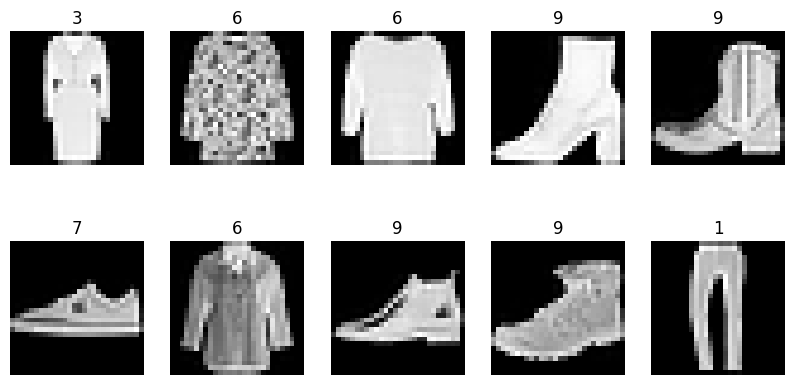

In [ ]:
# Display Sample Images
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(
    2,
    5,
    figsize=(10,5)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    ax.set_title(
        labels[i].item()
    )

    ax.axis("off")

plt.show()

# Create Model WITHOUT BatchNorm

In [ ]:
# 6 layers.
# Matches project requirement.
class NoBatchNorm(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784,512),
            nn.ReLU(),

            nn.Linear(512,256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,10)
        )

    def forward(self,x):

        return self.network(x)

# Create Model WITH BatchNorm

In [ ]:
class WithBatchNorm(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784,512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32,10)
        )

    def forward(self,x):

        return self.network(x)
# Only BatchNorm layers changed.
# Everything else remains identical.
# This is important for a controlled experiment.

In [ ]:
# Training Function
def train_model(model, epochs=10):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    losses = []

    model.to(device)

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        avg_loss = (
            running_loss /
            len(train_loader)
        )

        losses.append(avg_loss)

        print(
            f"Epoch {epoch+1}: {avg_loss:.4f}"
        )

    return losses

In [ ]:
# Accuracy Function
def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, pred = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                pred == labels
            ).sum().item()

    return (
        100 * correct / total
    )

In [ ]:
# Train WITHOUT BatchNorm
model_no_bn = NoBatchNorm()
no_bn_losses = train_model(
    model_no_bn
)

Epoch 1: 0.6023
Epoch 2: 0.3928
Epoch 3: 0.3501
Epoch 4: 0.3249
Epoch 5: 0.3025
Epoch 6: 0.2888
Epoch 7: 0.2762
Epoch 8: 0.2611
Epoch 9: 0.2507
Epoch 10: 0.2422


In [ ]:
no_bn_accuracy = evaluate(
    model_no_bn
)

print(no_bn_accuracy)

88.78


In [ ]:
# Run The BatchNorm Version
model_bn = WithBatchNorm()
# Train it
bn_losses = train_model(
    model_bn
)

Epoch 1: 0.5370
Epoch 2: 0.3682
Epoch 3: 0.3266
Epoch 4: 0.3029
Epoch 5: 0.2816
Epoch 6: 0.2631
Epoch 7: 0.2465
Epoch 8: 0.2324
Epoch 9: 0.2202
Epoch 10: 0.2084


In [ ]:
bn_accuracy = evaluate(
    model_bn
)

print(bn_accuracy)

88.92


# Experiment 3: Making the epochs from 10 to 20 (Extended Training)

In [ ]:
model_no_bn_20 = NoBatchNorm()

no_bn_losses_20 = train_model(
    model_no_bn_20,
    epochs=20
)

Epoch 1: 0.6498
Epoch 2: 0.4064
Epoch 3: 0.3595
Epoch 4: 0.3302
Epoch 5: 0.3089
Epoch 6: 0.2913
Epoch 7: 0.2796
Epoch 8: 0.2678
Epoch 9: 0.2562
Epoch 10: 0.2471
Epoch 11: 0.2368
Epoch 12: 0.2322
Epoch 13: 0.2205
Epoch 14: 0.2125
Epoch 15: 0.2067
Epoch 16: 0.2003
Epoch 17: 0.1891
Epoch 18: 0.1862
Epoch 19: 0.1786
Epoch 20: 0.1733


In [ ]:
model_bn_20 = WithBatchNorm()

bn_losses_20 = train_model(
    model_bn_20,
    epochs=20
)

Epoch 1: 0.5537
Epoch 2: 0.3706
Epoch 3: 0.3283
Epoch 4: 0.3001
Epoch 5: 0.2803
Epoch 6: 0.2624
Epoch 7: 0.2450
Epoch 8: 0.2322
Epoch 9: 0.2167
Epoch 10: 0.2069
Epoch 11: 0.1974
Epoch 12: 0.1855
Epoch 13: 0.1745
Epoch 14: 0.1650
Epoch 15: 0.1577
Epoch 16: 0.1492
Epoch 17: 0.1410
Epoch 18: 0.1335
Epoch 19: 0.1276
Epoch 20: 0.1199


In [ ]:
no_bn_20_accuracy = evaluate(model_no_bn_20)

print("No BatchNorm (20 Epochs):", no_bn_20_accuracy)

No BatchNorm (20 Epochs): 89.28


In [ ]:
bn_20_accuracy = evaluate(model_bn_20)

print("BatchNorm (20 Epochs):", bn_20_accuracy)

BatchNorm (20 Epochs): 89.39


# Loss Graph (10 Epochs)

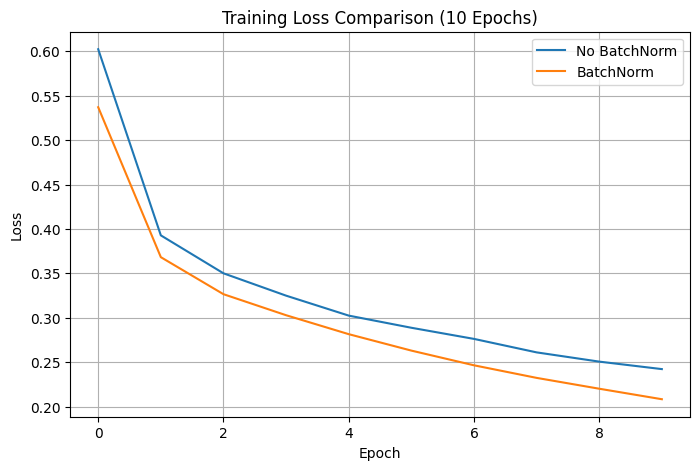

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(no_bn_losses, label="No BatchNorm")

plt.plot(bn_losses, label="BatchNorm")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Comparison (10 Epochs)")

plt.legend()

plt.grid(True)

plt.show()

# Loss Graph (20 Epochs)

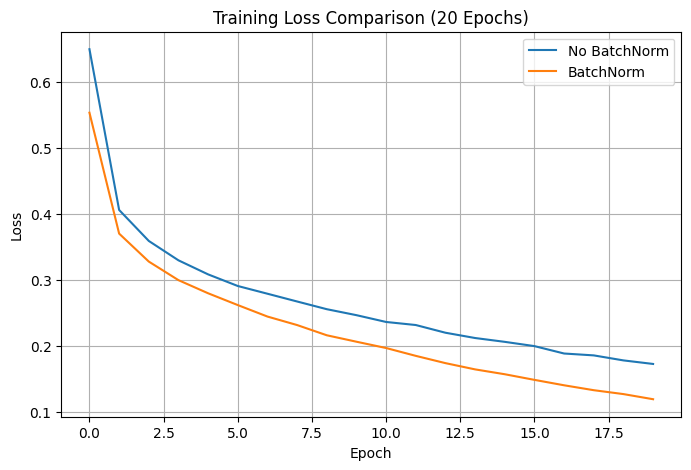

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(no_bn_losses_20, label="No BatchNorm")

plt.plot(bn_losses_20, label="BatchNorm")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Comparison (20 Epochs)")

plt.legend()

plt.grid(True)

plt.show()

# Accuracy Comparison Graph (10 Epochs)

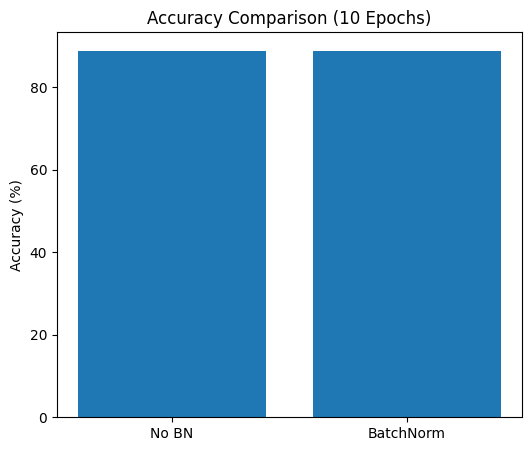

In [ ]:
models = [
    "No BN",
    "BatchNorm"
]

accuracies = [
    88.78,
    88.92
]

plt.figure(figsize=(6,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")

plt.title("Accuracy Comparison (10 Epochs)")

plt.show()

# Accuracy Comparison Graph (20 Epochs)

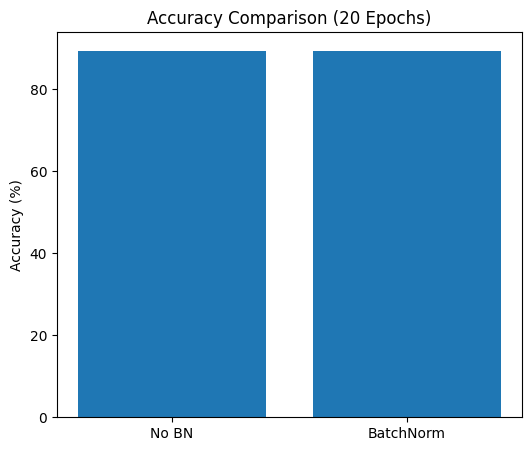

In [ ]:
models = [
    "No BN",
    "BatchNorm"
]

accuracies = [
    no_bn_20_accuracy,
    bn_20_accuracy
]

plt.figure(figsize=(6,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")

plt.title("Accuracy Comparison (20 Epochs)")

plt.show()

# Conclusion

This experiment investigated the effect of Batch Normalization on deep neural network training using the Fashion-MNIST dataset.

## Final Results

### After 10 Epochs

| Model | Accuracy (%) |
|---------|---------|
| Without Batch Normalization | 88.78 |
| With Batch Normalization | 88.92 |

### After 20 Epochs

| Model | Accuracy (%) |
|---------|---------|
| Without Batch Normalization | 89.28 |
| With Batch Normalization | 89.39 |

---

## Observations

- Both models achieved similar classification accuracy.
- The Batch Normalization model consistently maintained lower training loss.
- Loss curves show smoother and faster convergence when Batch Normalization is used.
- Training became more stable due to normalized activations within each mini-batch.

---

## Key Learning

Batch Normalization does not always produce large improvements in final accuracy, but it significantly improves the optimization process.

The experiment demonstrates that Batch Normalization helps deep neural networks train more efficiently by reducing internal activation shifts and improving convergence stability.